In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))


from helpers.mysql_connections import create_mysql_engine

import pandas as pd
import matplotlib.pyplot as plt

engine = create_mysql_engine()

query = 'SELECT * FROM results'
df_results = pd.read_sql( query, engine )
df_results.head(5)




,id,campaign_id,user_id,r_id,email,first_name,last_name,status,ip,latitude,longitude,position,send_date,reported,modified_date
0,1,1,4393,RID000104393000001zhgGnGad,jose.fuentes4393@corp-demo.com,Jose,Fuentes,Email Opened,166.218.131.95,13.812771,-89.275232,Jefe de Taller,None,0,2021-02-13 23:43:40
1,2,1,937,RID000100937000002H2tW3Q7K,carmen.mendez937@ventas-demo.com,Carmen,Mendez,Email Opened,142.32.201.148,13.659711,-89.152845,Recepcionista,None,0,2021-02-13 10:58:40
2,3,1,2521,RID000102521000003W6F2zLQZ,samuel.navarro2521@industrial-demo.com,Samuel,Navarro,Email Opened,197.170.111.248,13.819245,-89.330966,Supervisor de Mantenimiento,None,0,2021-02-13 02:42:40
3,4,1,4105,RID000104105000004zVlqsmwj,diana.ruiz4105@corp-demo.com,Diana,Ruiz,Email Opened,64.1.36.163,13.686098,-89.308195,Tecnico de Soporte,None,0,2021-02-14 12:13:40
4,5,1,1225,RID000101225000005JEMdEMFB,ernesto.acosta1225@servicios-demo.com,Ernesto,Acosta,Email Opened,117.130.146.252,13.749303,-89.196605,Asistente de Finanzas,None,0,2021-02-14 21:54:40


In [2]:

## Porcentage of emails with URL clicked

q_submitted_data = 'SELECT * FROM results WHERE status = "Submitted Data"'
## Total of emails

total_emails = len(df_results)

## Number of emails with URLs that were clicked

df_emails_submitted_data = pd.read_sql( q_submitted_data, engine )
emails_submitted_data = len(df_emails_submitted_data)

## Metrics Calculations

emails_submitted_data_index = round( emails_submitted_data / total_emails, 3)

emails_submitted_data_prtg = round( emails_submitted_data / total_emails * 100,2)

other_emails_prtg = round( ( total_emails - emails_submitted_data ) / total_emails * 100,2)

emails_submitted_data_dict = {
    'Emails Submitted Data': [emails_submitted_data],
    'Index' : [emails_submitted_data_index],
    '%': [f'{emails_submitted_data_prtg}%'],
    'Other Emails %': [f'{other_emails_prtg}%']
}


df_emails_submitted_data_metrics = pd.DataFrame( emails_submitted_data_dict, index= ['Values'], columns = ['Emails Submitted Data', 'Index', '%', 'Other Emails %']  )

---

# **Presentacion de la Informacion**

---

In [3]:
display( df_emails_submitted_data_metrics )

,Emails Submitted Data,Index,%,Other Emails %
Values,401,0.06,6.02%,93.98%


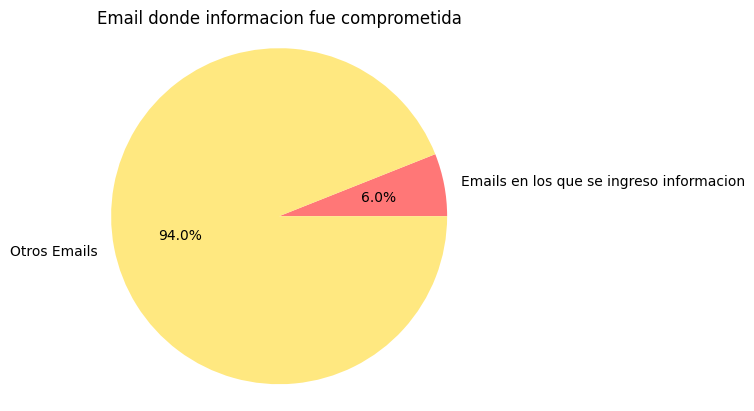

In [4]:
labels = ['Emails en los que se ingreso informacion', 'Otros Emails']
values = [emails_submitted_data_prtg, other_emails_prtg]
colors = ["#FF7777", "#FFE880"]

plt.pie( values, labels=labels, colors=colors,  autopct='%1.1f%%')

plt.title('Email donde informacion fue comprometida')
plt.axis('equal')

plt.show()